# From a Messy CSV to an Actionable Data Report in 10 Minutes

Real transaction data is never clean. This notebook takes a real, messy retail
dataset — 541,909 e-commerce transactions — and walks it all the way to a
business decision, using [dextra](https://pypi.org/project/pydextra/), a data
analysis toolkit built on one rule: **every automatic decision is disclosed,
and you stay in charge.**

The route, in five steps:

1. **Peek** at the file — then learn why the head of a file can lie, and how a measured load catches what a glance misses.
2. **Audit** data quality before touching a single cell.
3. **Clean in stages** — names, types, business rules, duplicates, missing values — each step showing its work.
4. **Analyse** revenue, markets, products and returns.
5. **Ship** a self-contained HTML report and state the decision.

**Dataset:** [Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) —
every transaction of a UK-based online gift retailer between Dec 2010 and Dec 2011.
Chen, D. (2015). UCI Machine Learning Repository.
DOI: [10.24432/C5BW33](https://doi.org/10.24432/C5BW33) — License:
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

## 0 · Setup

One install brings everything we need (the `io` extra adds Excel support and
smarter CSV detection):

In [1]:
%pip install -q "pydextra[io]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import dextra as dx

print("dextra", dx.__version__, "| pandas", pd.__version__)

dextra 0.5.1 | pandas 3.0.3


### Get the data

The next cell downloads the official UCI archive once (~23 MB), extracts the
Excel file, and flattens it to a raw CSV — the shape most real-world exports
arrive in. Everything is cached under `data/`, so re-runs cost nothing.

In [3]:
import urllib.request, zipfile
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
ZIP_PATH = DATA_DIR / "online_retail.zip"
CSV_PATH = DATA_DIR / "online_retail_raw.csv"
UCI_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

if not CSV_PATH.exists():
    if not ZIP_PATH.exists():
        print("Downloading from UCI (~23 MB) ...")
        urllib.request.urlretrieve(UCI_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)
    xlsx = next(DATA_DIR.glob("*.xlsx"))
    print(f"Converting {xlsx.name} -> CSV (one-time, ~2 min) ...")
    pd.read_excel(xlsx).to_csv(CSV_PATH, index=False)

print(f"Ready: {CSV_PATH} ({CSV_PATH.stat().st_size / 1e6:.1f} MB)")

Ready: data\online_retail_raw.csv (48.6 MB)


## 1 · Look before you load

`dx.peek` proposes a complete load plan — encoding, delimiter, header row, a
type for every column, and how confident it is about each decision —
**without loading anything yet:**

In [4]:
plan = dx.peek(CSV_PATH)

source=source | encoding=utf-8 | sep=',' | header=row 0 | 10x8
     column          dtype  parsed_%  null_%  n_distinct problem   action confidence
  InvoiceNo          int64  100.0000  0.0000           3                   confirmed
  StockCode         object  100.0000  0.0000          10                   confirmed
Description         object  100.0000  0.0000          10                   confirmed
   Quantity          int64  100.0000  0.0000           4                   confirmed
InvoiceDate datetime64[us]  100.0000  0.0000           3                   confirmed
  UnitPrice        float64  100.0000  0.0000           7                   confirmed
 CustomerID        float64  100.0000  0.0000           2                   confirmed
    Country         object  100.0000  0.0000           1         category  confirmed
Decision: Loaded 10 rows x 8 cols from 'source' [encoding=utf-8, sep=',', header=row 0]; coerced 5 column(s) (datetime64[us], float64, int64); 0 cell(s) failed -> NaN; 0 am

### Read the fine print — then distrust it

`peek` reads the head of the file, and the head looks *perfect*: `InvoiceNo`
parses as clean integers, 100% confidence. On a quick glance, this file would
sail straight through:

In [5]:
plan["columns"]["InvoiceNo"]   # the head of the file: looks like clean integers

{'dtype': 'int64',
 'coerced_from': 'object',
 'parse_rate': 1.0,
 'n_failed': 0,
 'confidence': 'confirmed',
 'reason': 'int64 at parse_rate=1.00',
 'suggest': None}

The head lied. `dx.load` does what a glance cannot: it **measures every cell
in every column**. Across the full file, only ~98% of `InvoiceNo` parses as
numeric — because in this dataset an invoice number starting with **"C" marks
a cancellation** — a return. Coerce the column to numbers and every
cancellation becomes `NaN`: an entire class of business events, silently
destroyed. `load` refuses to keep that quiet — it warns, it counts, and with
`return_params=True` it hands back the **exact plan it executed** so you can
correct it. Watch:

In [6]:
naive, plan = dx.load(CSV_PATH, show=False, return_params=True)

lost = int(naive["InvoiceNo"].isna().sum())
print(f"Invoice numbers destroyed by numeric coercion: {lost:,}")

Invoice numbers destroyed by numeric coercion: 9,291


C:\Users\manim\AppData\Local\Temp\ipykernel_25336\977389890.py:1: DextraLoaderWarning: load: ambiguous decision(s): column 'InvoiceNo': ambiguous - float64 at parse_rate=0.98
  naive, plan = dx.load(CSV_PATH, show=False, return_params=True)


### The fix: write your domain knowledge into the plan

The plan is a plain, replayable dict. Invoice and product codes are *labels*,
not quantities — we override those two decisions and reload. Same file, zero
loss, and the correction is now **documented, versionable code:**

In [7]:
plan["columns"]["InvoiceNo"]["dtype"] = "object"   # invoices are labels
plan["columns"]["StockCode"]["dtype"] = "object"   # product codes too

df = dx.load(CSV_PATH, params=plan, show=False)    # deterministic replay

n_cancel = int(df["InvoiceNo"].astype(str).str.startswith("C").sum())
print(f"Cancellation invoices preserved: {n_cancel:,}")
print(f"InvoiceNo values lost: {int(df['InvoiceNo'].isna().sum())}")

Cancellation invoices preserved: 9,288
InvoiceNo values lost: 0


## 2 · Audit before touching anything

`dx.audit` is a data-quality X-ray — missingness, duplicates, outliers, type
issues, memory — in one read-only call:

Cleaning audit for: retail  (shape=541909x8, memory=144.19 MB)
--------------------------------------------------------------

Per-column profile
------------------


,dtype,n_missing,pct_missing,n_unique,cardinality_pct,memory_kb,sample_value,suggested_action
column,,,,,,,,
InvoiceNo,object,0,0.00%,"25,900",4.78%,"29,115.64","536,365.00",OK
StockCode,object,0,0.00%,"4,070",0.75%,"28,623.32",85123A,OK
Description,object,"1,454",0.27%,"4,223",0.78%,"39,969.95",WHITE HANGING HEART T-LIGHT HOLDER,review
Quantity,int64,0,0.00%,722,0.13%,"4,233.79",6.00,OK
InvoiceDate,datetime64[us],0,0.00%,"23,260",4.29%,"4,233.79",2010-12-01 08:26:00,OK
UnitPrice,float64,0,0.00%,"1,630",0.30%,"4,233.79",2.55,OK
CustomerID,float64,"135,080",24.93%,"4,372",0.81%,"4,233.79","17,850.00",impute_median
Country,object,0,0.00%,38,0.01%,"33,010.12",United Kingdom,OK



Global quality scores
---------------------


,score (0-100)
completeness,96.85
uniqueness,99.03
consistency,50.00
OVERALL,88.13



Cleaning trail (1 step(s) applied)
----------------------------------


,stage,function,timestamp,decision
#,,,,
1,loader,load,2026-07-04T13:18:53Z,Replayed a stored load plan.



Decision: quality_score = 88.13/100.  Suggested actions across 8 column(s): drop_column=0, drop_constant=0, impute=1, review=1.  Duplicate rows: 5268.  Complete rows: 406829/541909.



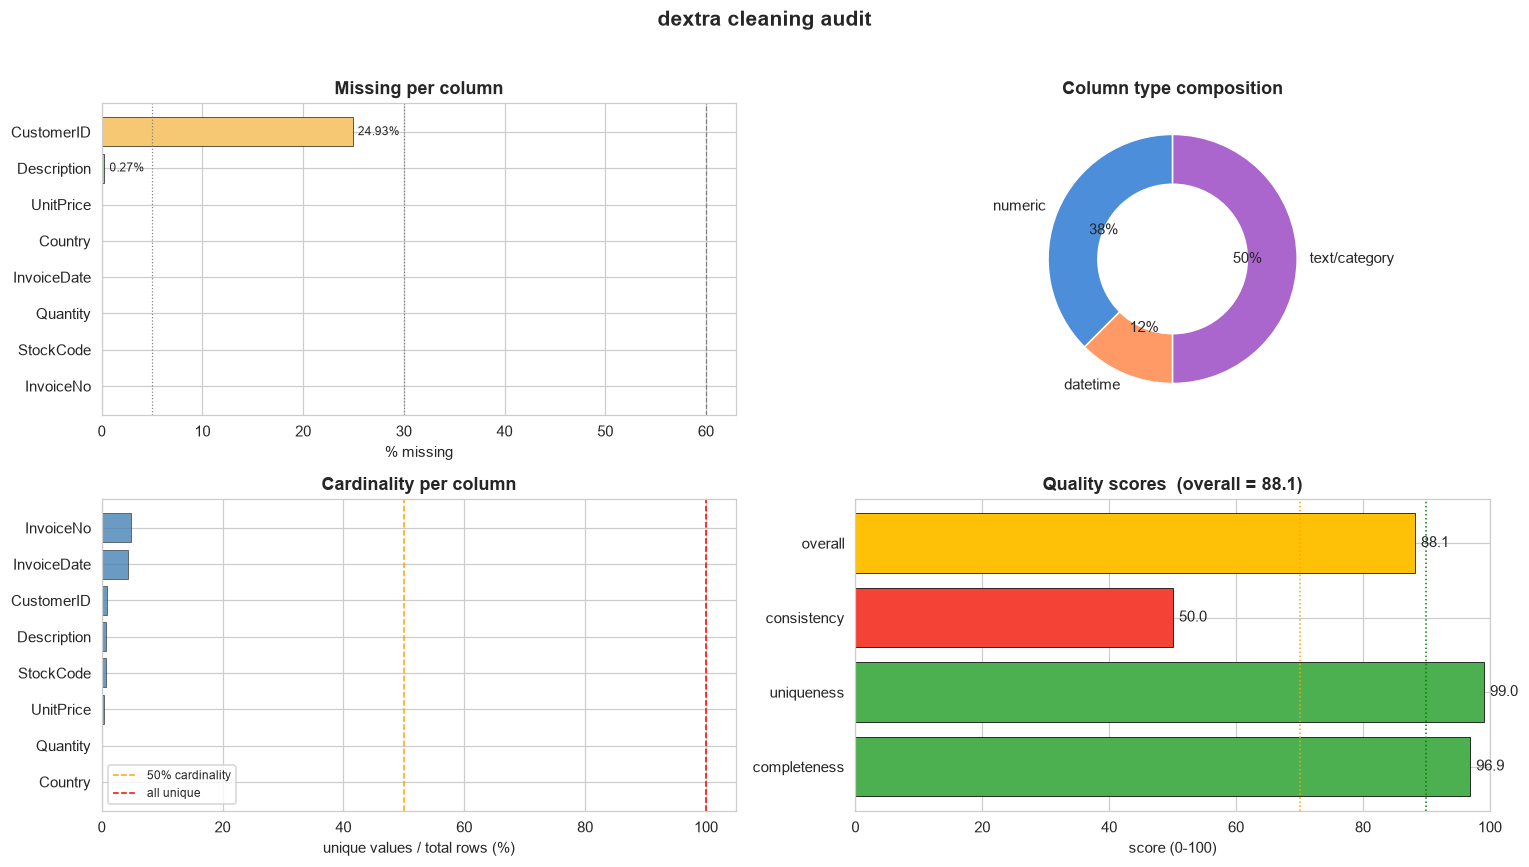

In [8]:
dx.audit(df, df_name="retail")

The audit gives totals; two read-only inspectors show the *evidence* behind
them:

Missing-value inspection for: df
--------------------------------

Per-column profile:


,dtype,n_missing,pct_missing,suggested_strategy
column,,,,
InvoiceNo,object,0,0.00%,keep
StockCode,object,0,0.00%,keep
Description,object,"1,454",0.27%,mode
Quantity,int64,0,0.00%,keep
InvoiceDate,datetime64[us],0,0.00%,keep
UnitPrice,float64,0,0.00%,keep
CustomerID,float64,"135,080",24.93%,mean
Country,object,0,0.00%,keep



First 10 of 135080 rows with missing values:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,which_cols_missing,n_missing_in_row
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,"Description, CustomerID",2
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,CustomerID,1
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,CustomerID,1
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,CustomerID,1
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,CustomerID,1
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom,CustomerID,1
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,CustomerID,1
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom,CustomerID,1
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom,CustomerID,1
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom,CustomerID,1



Decision: 135080 row(s) across 2 column(s) have missing values. Suggested per-column strategies: {'Description': 'mode', 'CustomerID': 'mean'}. Call `dx.impute(df, strategy=...)` once you have decided.



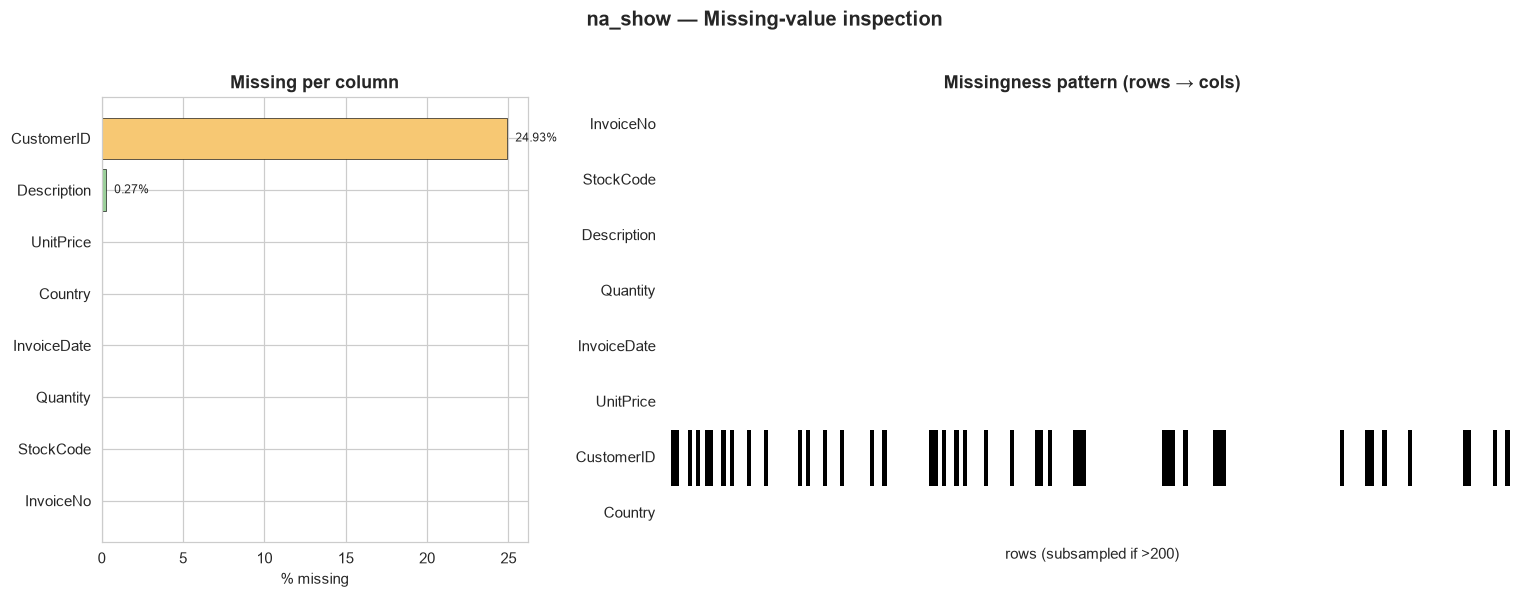

In [9]:
dx.nascan(df)

Duplicate inspection for: df
----------------------------

First 20 of 10147 duplicate row(s) in 4879 group(s):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,dup_group_id,group_size,is_first_in_group
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,1,2,True
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,1,2,False
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2,2,False
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2,2,True
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,3,2,True
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,3,2,False
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,4,2,True
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,4,2,False
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,5,2,True
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,5,2,False



Decision: 10147 duplicate row(s) in 4879 group(s). Either call `dx.dedup(df, drop_indices=[...])` after choosing rows, or `dx.dedup(df, keep='first'|'last')` for a bulk action.



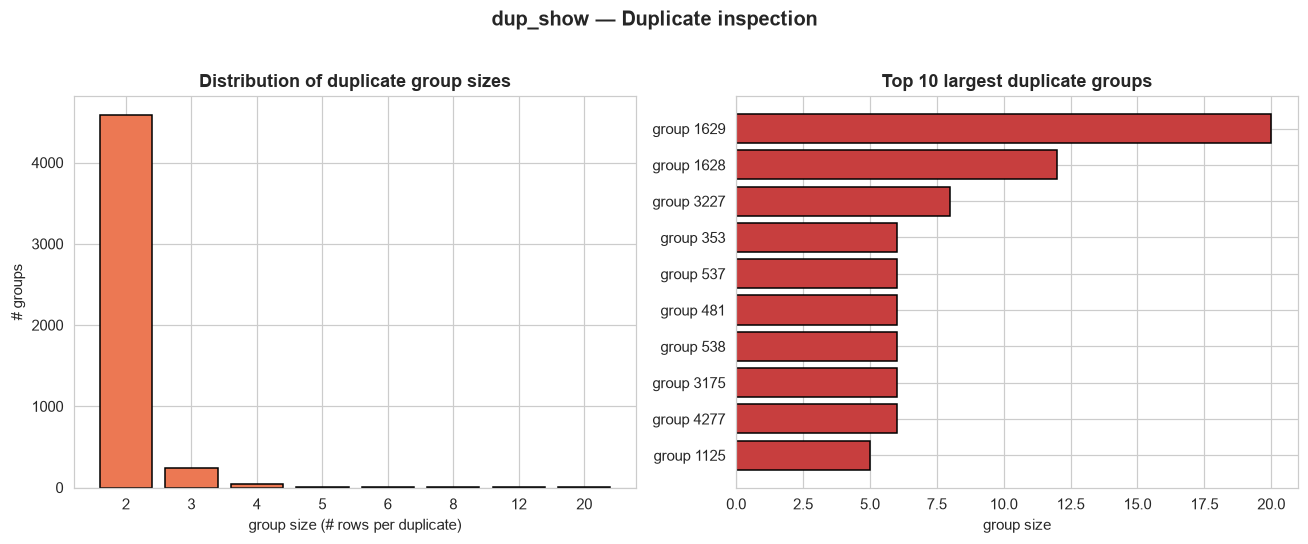

In [10]:
dx.dupscan(df)

## 3 · Structure first: names, then types

Cleaning has an order — fix structure before values, or you fix everything
twice. `tidycols` standardises the column names; `recast` then coerces every
column to its best type.

One caveat we already understand: `recast` measures that ~98% of `invoiceno`
parses as numeric, so left alone it would repeat the loader's destructive
guess. Identity columns are a *human* decision — we declare them, once, in the
schema. Note also that these functions **never mutate your frame**: they
return a new one (`return_df=True`).

Structural cleanup for: df
--------------------------

Column renames (8):


,before,after
0,InvoiceNo,invoiceno
1,StockCode,stockcode
2,Description,description
3,Quantity,quantity
4,InvoiceDate,invoicedate
5,UnitPrice,unitprice
6,CustomerID,customerid
7,Country,country



Whitespace stripped from cells:


,n_cells_stripped
column,
description,"113,452"



Decision: Renamed 8 column(s); stripped whitespace in 113452 cell(s).



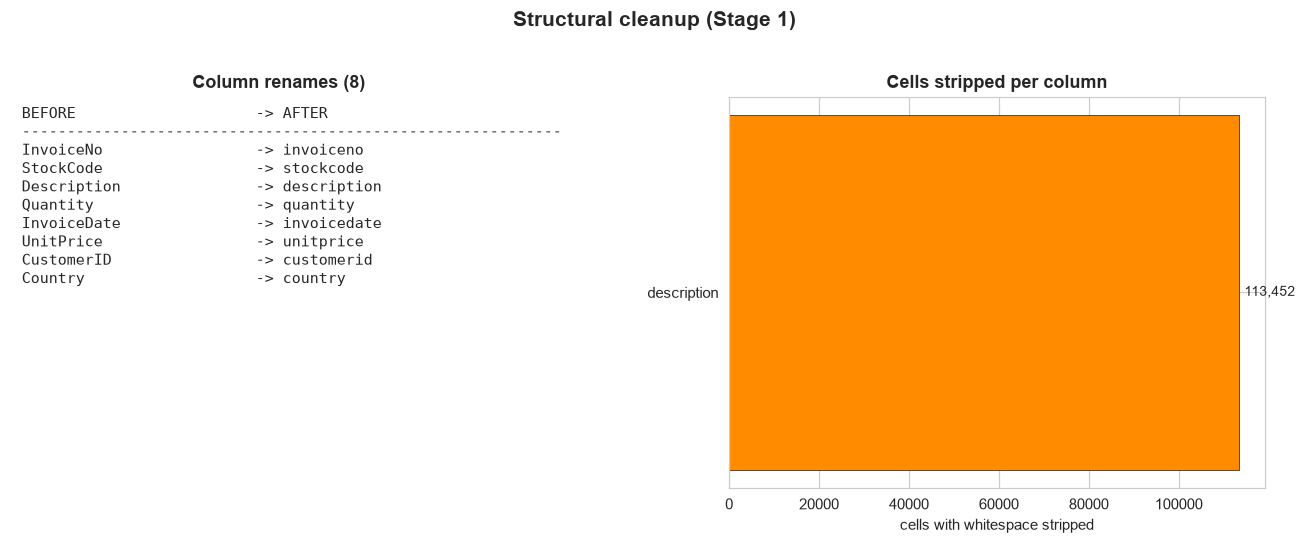

In [11]:
df = dx.tidycols(df, return_df=True)

Type coercion for: df  (schema=provided)
----------------------------------------


,before,after,memory_before_kb,memory_after_kb,saved_kb
column,,,,,
invoiceno,object,string,"29,115.64","29,115.64",0.00
stockcode,object,string,"28,623.32","28,623.32",0.00
country,object,category,"33,010.12",531.46,"32,478.66"



Decision: Coerced 3 column(s); net memory delta = +32478.66 KB.



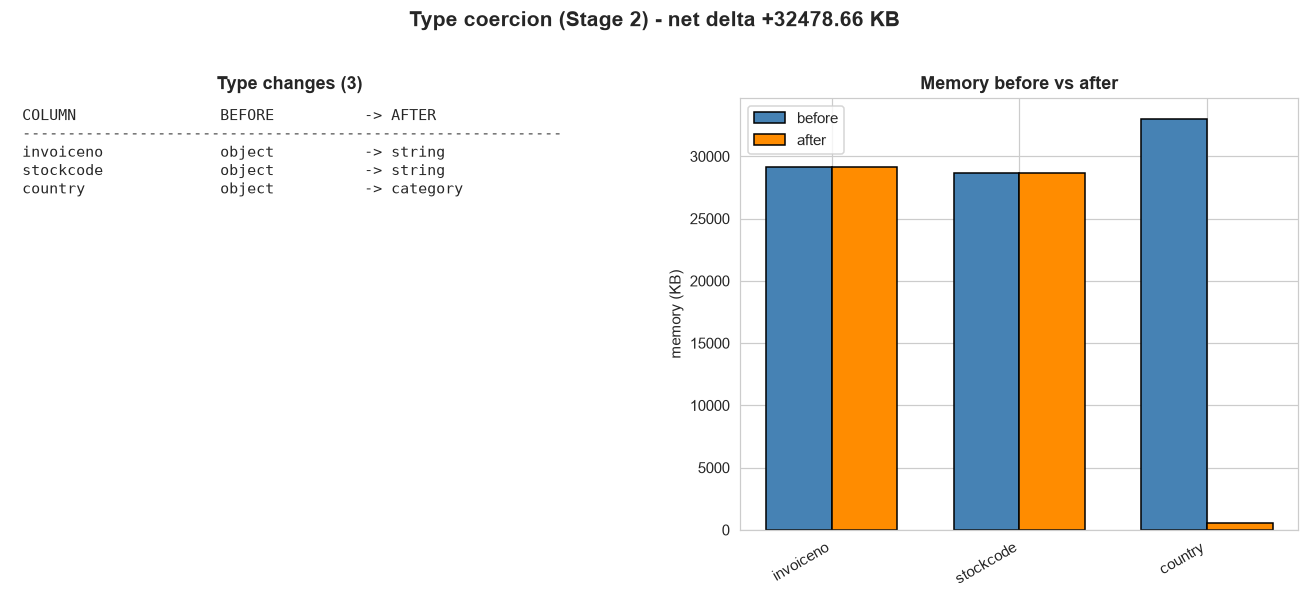

In [12]:
df = dx.recast(df, schema={"invoiceno": "string", "stockcode": "string"},
               return_df=True)

## 4 · Business rules before deletion

The audit surfaced negative quantities and zero prices. A careless pipeline
would drop or clip them and move on. But **a negative quantity is not dirt —
it is a return**, and a zero price is a question (a sample? a giveaway? an
error?), not an answer. `dx.verify` turns domain knowledge into executable,
reportable rules:

Rule validation for: df  (3 rule(s))
------------------------------------


,severity,n_violations,pct_violations,status,description
rule,,,,,
positive_quantity,error,"10,624",1.96%,FAIL,Sales lines sell at least one unit; negatives ...
positive_price,error,"2,517",0.46%,FAIL,"Zero-price lines are giveaways, samples or err..."
known_customer,warning,"135,080",24.93%,FAIL,"Guest checkouts are allowed, but cap customer-..."



Decision: 0 PASS, 3 FAIL, 0 ERROR out of 3 rule(s).  144025 row(s) violate at least one rule.



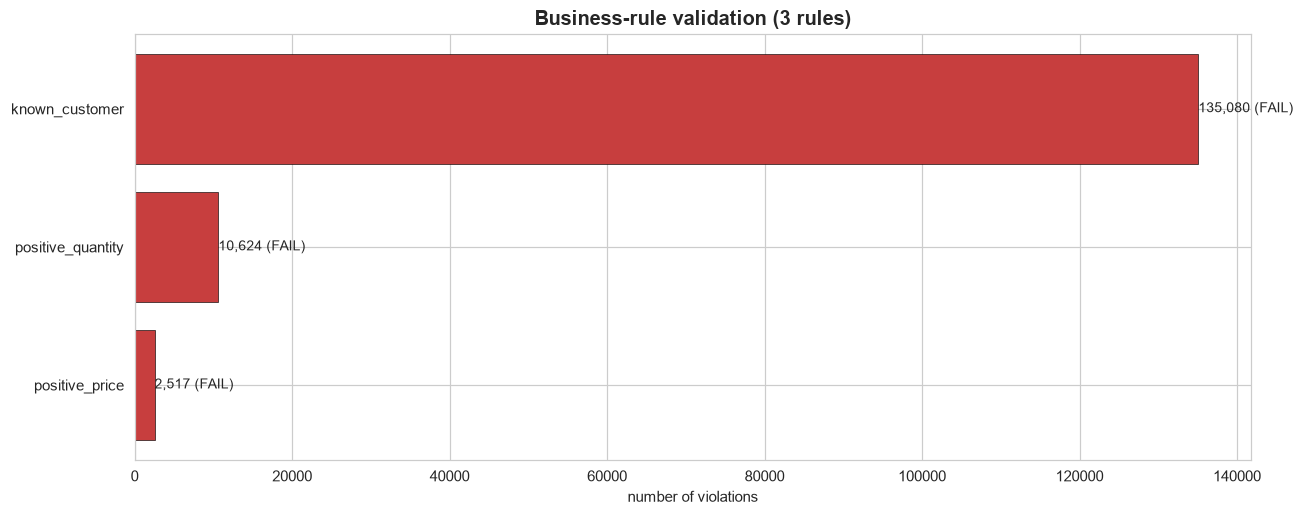

In [13]:
rules = [
    {"name": "positive_quantity", "check": "quantity > 0",
     "description": "Sales lines sell at least one unit; negatives are returns."},
    {"name": "positive_price", "check": "unitprice > 0",
     "description": "Zero-price lines are giveaways, samples or errors."},
    {"name": "known_customer",
     "check": lambda d: d["customerid"].notna(), "severity": "warning",
     "description": "Guest checkouts are allowed, but cap customer-level analysis."},
]
dx.verify(df, rules)

### Act on the rules: split, don't delete

Cancellations go to their own frame — they carry business signal we will cash
in later. What remains with a non-positive quantity or price is a small
residue of stock adjustments and errors; we set it aside rather than silently
erase it:

In [14]:
is_cancel = df["invoiceno"].astype(str).str.startswith("C")

returns  = df[is_cancel].copy()
oddities = df[~is_cancel & ((df["quantity"] <= 0) | (df["unitprice"] <= 0))].copy()
sales    = df[~is_cancel & (df["quantity"] > 0) & (df["unitprice"] > 0)].copy()

for name, frame in [("sales", sales), ("returns", returns), ("oddities", oddities)]:
    print(f"{name:<9} {len(frame):>7,} rows  ({len(frame) / len(df):.1%})")

print("\nInside the oddities bin (disclosure means you can always look):")
print(oddities["description"].value_counts(dropna=False).head(5).to_string())

sales     530,104 rows  (97.8%)
returns     9,288 rows  (1.7%)
oddities    2,517 rows  (0.5%)

Inside the oddities bin (disclosure means you can always look):
description
NaN        1454
check       159
?            47
damages      45
damaged      43


## 5 · Duplicates: the double-scan problem

`dupscan` showed identical rows — same invoice, same product, same minute. In
retail exports these are almost always double-entered scans, so we keep the
first occurrence. `dedup` reports exactly what it dropped:

Duplicate resolution for: sales
-------------------------------


,value
rows_before,"530,104"
rows_after,"524,878"
rows_removed,"5,226"
rows_in_duplicate_groups,"10,068"
duplicate_groups,"4,842"
subset,(all columns)
keep,first



Sample of removed duplicates (showing up to 5):


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom



Decision: Removed 5226 duplicate row(s) (10068 were part of 4842 duplicate group(s)).  Rows 530104 -> 524878.



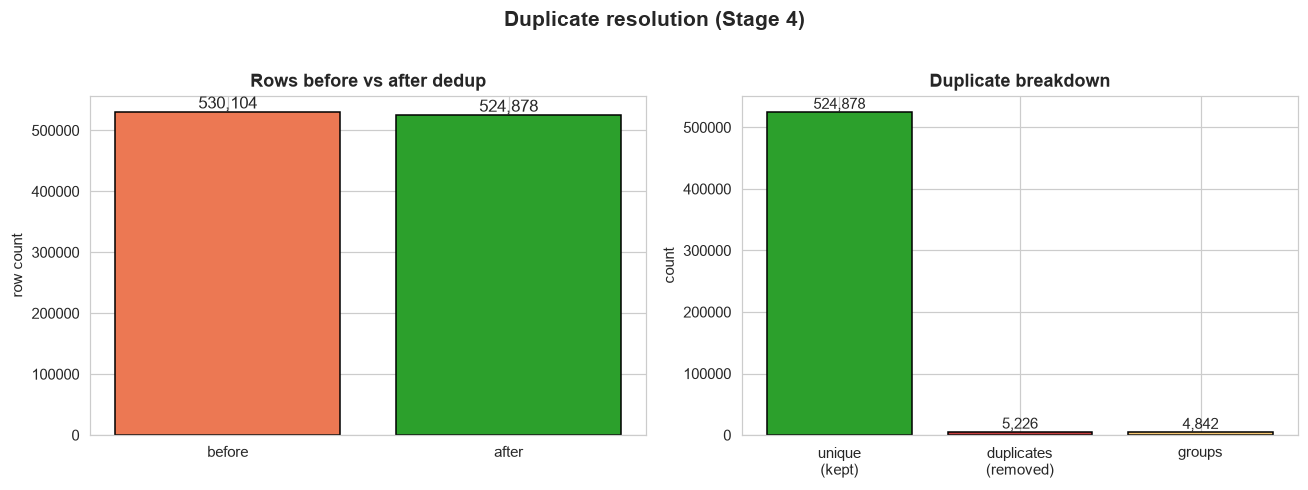

In [15]:
sales = dx.dedup(sales, return_df=True)

## 6 · Missing values, honestly

`missrep` measures per-column missingness and *recommends* a strategy — but a
recommendation is not an order. One row in four (25.2%) carries no `customerid`:
those are **guest checkouts**, not gaps to fill. Inventing IDs would corrupt
every customer-level number downstream, so we keep the rows for revenue
analysis and simply state the limitation.

(Thoughtlessly "fixing" data is also how models end up lying to you —
notebook 2 in this series is about exactly that.)

Missing values report for: sales
--------------------------------


,dtype,n_total,n_missing,pct_missing,sample_value,recommendation
column,,,,,,
invoiceno,string,"524,878",0,0.00%,"536,365.00",OK
stockcode,string,"524,878",0,0.00%,85123A,OK
description,object,"524,878",0,0.00%,WHITE HANGING HEART T-LIGHT HOLDER,OK
quantity,int64,"524,878",0,0.00%,6.00,OK
invoicedate,datetime64[us],"524,878",0,0.00%,2010-12-01 08:26:00,OK
unitprice,float64,"524,878",0,0.00%,2.55,OK
customerid,float64,"524,878","132,186",25.18%,"17,850.00",review
country,category,"524,878",0,0.00%,United Kingdom,OK



Decision: 132186 missing cell(s) across 1/8 column(s).  392,692 of 524,878 rows are complete (74.82%).



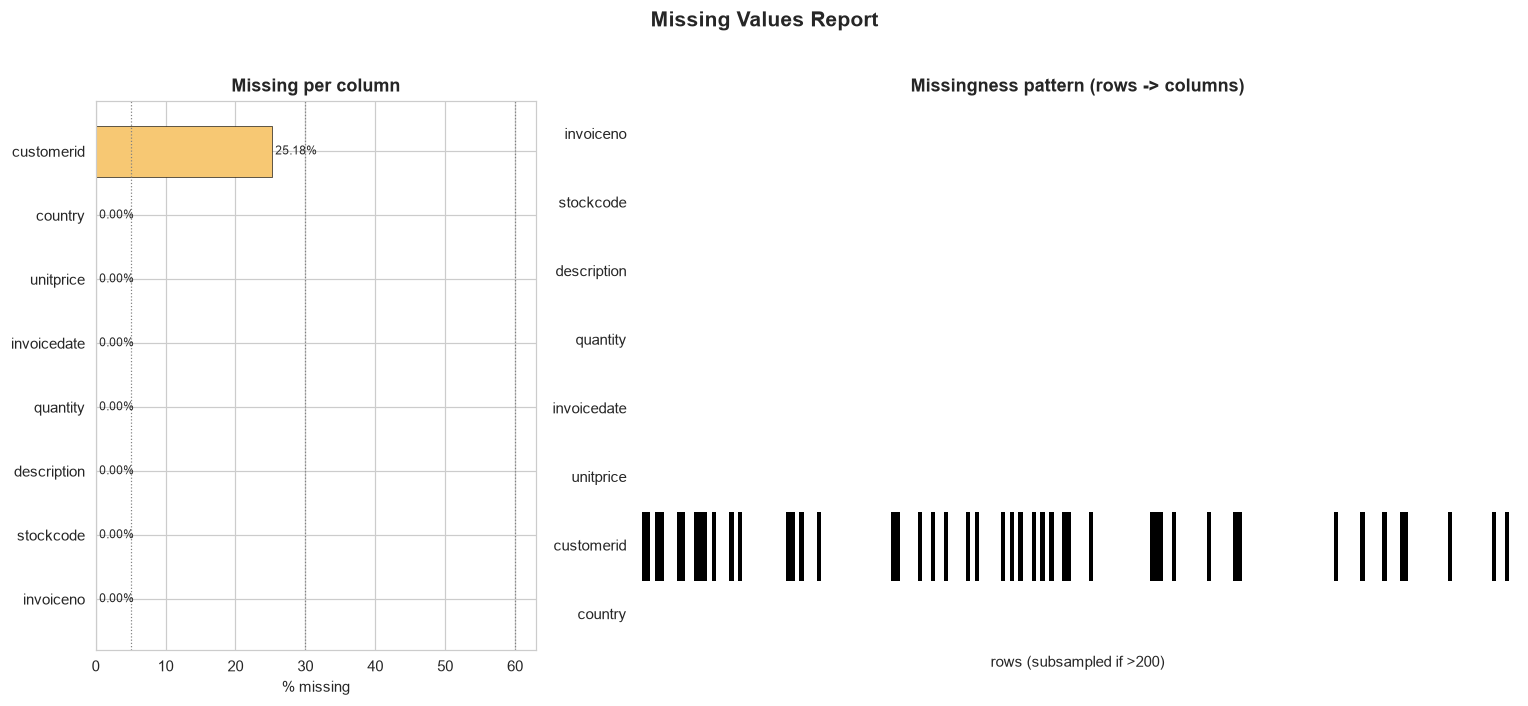

In [16]:
dx.missrep(sales)

In [17]:
sales = sales.assign(revenue=sales["quantity"] * sales["unitprice"])
dx.numdesc(sales, cols=["quantity", "unitprice", "revenue"], decimals=3)

Summary for: sales
------------------


,quantity,unitprice,revenue
mean,10.617,3.923,20.275
std,156.280,36.093,271.694
var,"24,423.448","1,302.707","73,817.394"
cv_%,"1,472.035",920.137,"1,340.016"
min,1.000,0.001,0.001
q1,1.000,1.250,3.900
median,4.000,2.080,9.920
diff_mean_median_%,165.415,88.585,104.389
q3,11.000,4.130,17.700
max,"80,995.000","13,541.330","168,469.600"


## 7 · Three business questions

The data is clean and every cleaning decision is on record. Now it earns its
keep:

1. **Where does the revenue come from?**
2. **What sells — and when?**
3. **What comes back?**

Frequency table for: sales[country]  (top 10)
---------------------------------------------


,count,pct,cumulative_count,cumulative_pct
country,,,,
United Kingdom,"479,985",91.45%,"479,985",91.45%
Germany,"9,025",1.72%,"489,010",93.17%
France,"8,392",1.60%,"497,402",94.77%
EIRE,"7,879",1.50%,"505,281",96.27%
Spain,"2,479",0.47%,"507,760",96.74%
Netherlands,"2,359",0.45%,"510,119",97.19%
Belgium,"2,031",0.39%,"512,150",97.58%
Switzerland,"1,958",0.37%,"514,108",97.95%
Portugal,"1,492",0.28%,"515,600",98.23%



Decision: 38 unique value(s).  Top category 'United Kingdom' covers 91.45%.  Missing: 0.



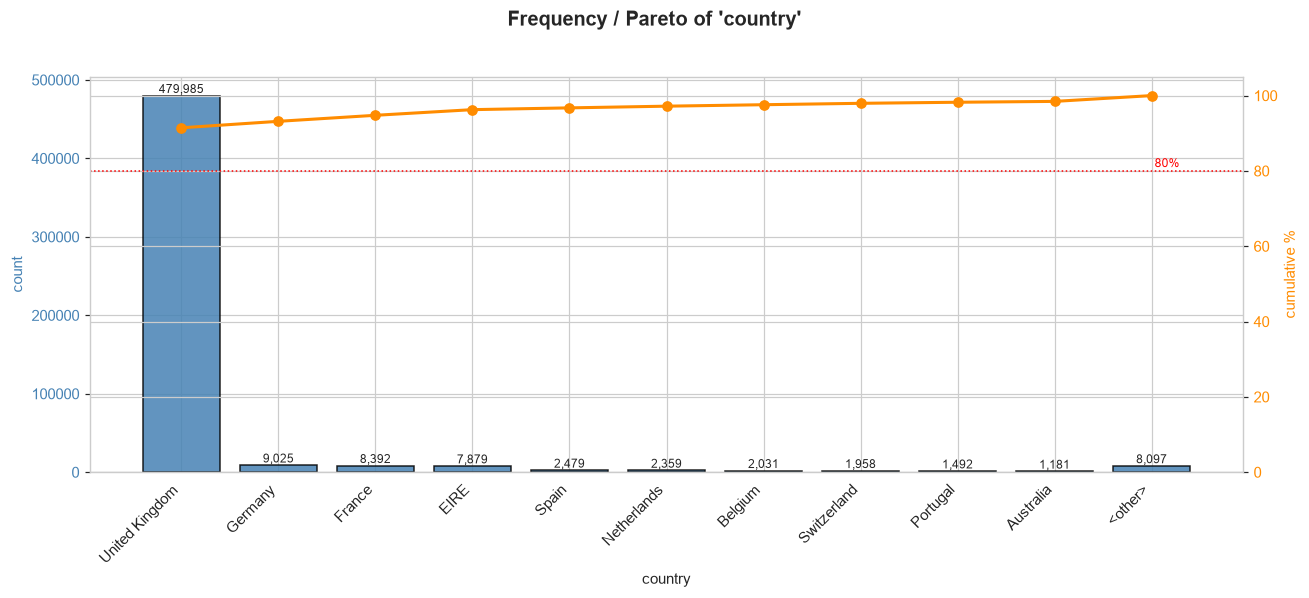

In [18]:
dx.freqtab(sales, "country", top_n=10)

Order counts are not money. Compare *revenue* across the top markets:

Group comparison for: top  by 'country'
---------------------------------------


,revenue.n,revenue.mean,revenue.std,revenue.median,revenue.min,revenue.max,revenue.iqr
country,,,,,,,
Belgium,"2,031",20.28,15.25,16.60,2.50,165.00,7.60
EIRE,"7,879",35.94,84.65,17.40,0.42,"2,365.20",15.78
France,"8,392",24.98,74.15,16.60,0.29,"4,161.06",10.92
Germany,"9,025",25.34,35.49,17.00,0.39,876.00,10.65
Netherlands,"2,359",121.00,164.05,91.80,0.39,"4,992.00",128.40
Spain,"2,479",24.83,70.41,15.00,0.21,"1,350.00",9.85
Switzerland,"1,958",29.15,35.27,17.70,0.42,360.00,18.00
United Kingdom,"479,985",18.75,282.78,8.50,0.00,"168,469.60",13.55


Decision (revenue): highest mean in 'Netherlands' (121.00), lowest in 'United Kingdom' (18.75).



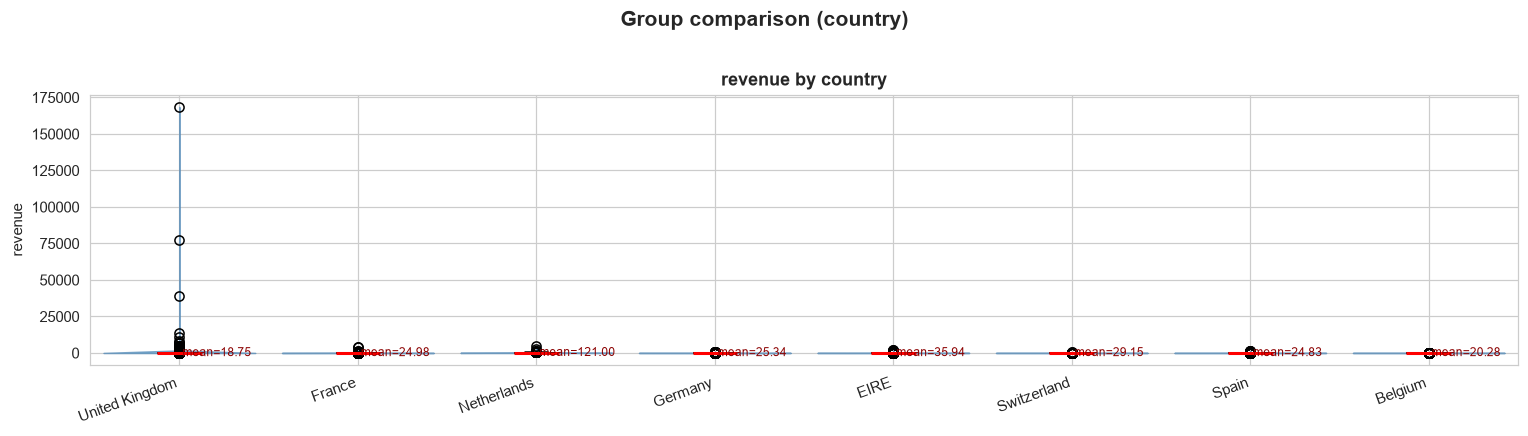

In [19]:
top8 = sales["country"].value_counts().head(8).index
top = sales[sales["country"].isin(top8)].copy()
top["country"] = top["country"].astype(str)

dx.gcmp(top, "country", "revenue")

Text(0, 0.5, 'GBP')

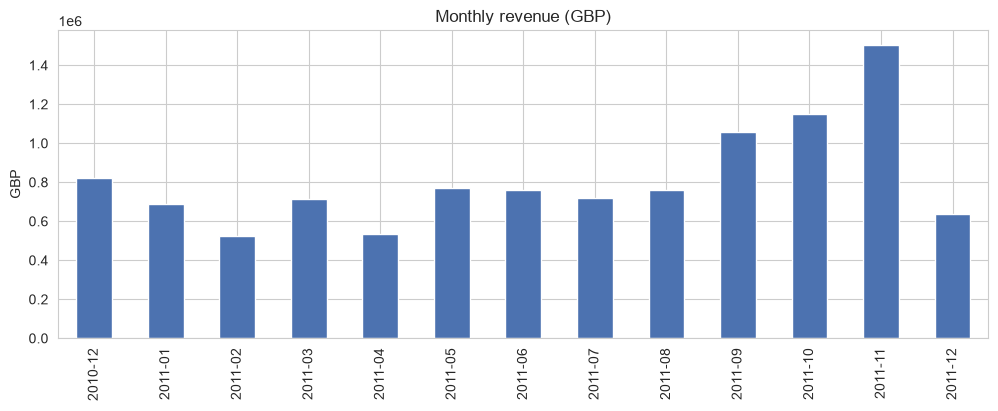

In [20]:
monthly = (sales.assign(month=sales["invoicedate"].dt.to_period("M").astype(str))
                .groupby("month")["revenue"].sum())

ax = monthly.plot(kind="bar", figsize=(12, 4), color="#4C72B0",
                  title="Monthly revenue (GBP)")
ax.set_xlabel("")
ax.set_ylabel("GBP")

In [21]:
(sales.groupby("description", observed=True)["revenue"]
      .sum().nlargest(10).round(0))

description
DOTCOM POSTAGE                        206249.0
REGENCY CAKESTAND 3 TIER              174157.0
PAPER CRAFT , LITTLE BIRDIE           168470.0
WHITE HANGING HEART T-LIGHT HOLDER    106237.0
PARTY BUNTING                          99445.0
JUMBO BAG RED RETROSPOT                94160.0
MEDIUM CERAMIC TOP STORAGE JAR         81701.0
POSTAGE                                78102.0
Manual                                 77753.0
RABBIT NIGHT LIGHT                     66870.0
Name: revenue, dtype: float64

Read that table before you report it — three of its rows are traps:

- **DOTCOM POSTAGE** and **POSTAGE** are shipping fees riding along in the
  product column, and `Manual` is a hand-keyed adjustment — service lines,
  not products.
- **PAPER CRAFT , LITTLE BIRDIE** is a phantom bestseller: a single
  80,995-unit order placed at 09:15 and fully cancelled at 09:27.
- One reading note for the chart above: the data ends on **9 December 2011**,
  so the last bar is a nine-day month, not a collapse.

The genuine best-seller is the **REGENCY CAKESTAND 3 TIER**. Aggregations
count whatever you feed them — they don't know your business. Reading the
table *is* the analysis.

### What comes back — cashing in the plan edit

Because section 1 saved the "C" invoices, the return side of the business is
still here to be measured. Most pipelines lose this table without ever
noticing:

In [22]:
returns = returns.assign(
    returned_value=-(returns["quantity"] * returns["unitprice"]),
    returned_units=-returns["quantity"],
)

return_rate = returns["returned_value"].sum() / sales["revenue"].sum()
print(f"Value returned vs value sold: {return_rate:.1%}\n")

top_returned = (returns.groupby("description", observed=True)
                       .agg(returned_units=("returned_units", "sum"),
                            cancel_invoices=("invoiceno", "nunique"))
                       .nlargest(10, "returned_units"))
print(top_returned.to_string())

Value returned vs value sold: 8.4%

                                     returned_units  cancel_invoices
description                                                         
PAPER CRAFT , LITTLE BIRDIE                   80995                1
MEDIUM CERAMIC TOP STORAGE JAR                74494               10
ROTATING SILVER ANGELS T-LIGHT HLDR            9376                4
Manual                                         4066              223
FAIRY CAKE FLANNEL ASSORTED COLOUR             3150                3
PINK BLUE FELT CRAFT TRINKET BOX               2617                4
WHITE HANGING HEART T-LIGHT HOLDER             2578               42
GIN + TONIC DIET METAL SIGN                    2030                7
HERB MARKER BASIL                              1527                2
FELTCRAFT DOLL MOLLY                           1447                5


The units column alone screams "quality problem". The `cancel_invoices`
column corrects the story: the biggest "return" in the entire dataset is
**one** cancelled order — 80,995 units entered at 09:15 and cancelled at
09:27 the same morning. Recurring, many-invoice products further down the
list are the genuine quality candidates. The mega-cancellations point to a
different fix entirely: **confirm unusually large orders at entry.**

## 8 · One call, one report

`edareport` compiles the cleaned frame into a single self-contained HTML file —
overview, histograms, correlations, categorical breakdowns — ready for a
stakeholder who will never open a notebook:

In [23]:
dx.edareport(sales, out="retail_eda_report.html",
             title="Online Retail - cleaned sales EDA")

print(f"\nReport size: {Path('retail_eda_report.html').stat().st_size / 1e6:.1f} MB")

,dtype,n_total,n_missing,pct_missing,sample_value,recommendation
column,,,,,,
invoiceno,string,"524,878",0,0.00%,"536,365.00",OK
stockcode,string,"524,878",0,0.00%,85123A,OK
description,object,"524,878",0,0.00%,WHITE HANGING HEART T-LIGHT HOLDER,OK
quantity,int64,"524,878",0,0.00%,6.00,OK
invoicedate,datetime64[us],"524,878",0,0.00%,2010-12-01 08:26:00,OK
unitprice,float64,"524,878",0,0.00%,2.55,OK
customerid,float64,"524,878","132,186",25.18%,"17,850.00",review
country,category,"524,878",0,0.00%,United Kingdom,OK
revenue,float64,"524,878",0,0.00%,15.30,OK


,method,n_valid,n_outliers,pct_outliers,q1,q3,iqr,lower_bound,upper_bound
column,,,,,,,,,
quantity,iqr,"524,878","27,111",5.17%,1.00,11.00,10.00,-14.00,26.00
unitprice,iqr,"524,878","37,827",7.21%,1.25,4.13,2.88,-3.07,8.45
customerid,iqr,"392,692",0,0.00%,"13,955.00","16,791.00","2,836.00","9,701.00","21,045.00"
revenue,iqr,"524,878","42,624",8.12%,3.90,17.70,13.80,-16.80,38.40


,quantity,unitprice,customerid,revenue
mean,10.62,3.92,"15,287.84",20.28
std,156.28,36.09,"1,713.54",271.69
var,"24,423.45","1,302.71","2,936,217.79","73,817.39"
cv_%,"1,472.03",920.14,11.21,"1,340.02"
min,1.00,0.00,"12,346.00",0.00
q1,1.00,1.25,"13,955.00",3.90
median,4.00,2.08,"15,150.00",9.92
diff_mean_median_%,165.42,88.59,0.91,104.39
q3,11.00,4.13,"16,791.00",17.70
max,"80,995.00","13,541.33","18,287.00","168,469.60"


,count,pct,cumulative_count,cumulative_pct
invoiceno,,,,
573585,"1,114",0.21%,"1,114",0.21%
581219,749,0.14%,"1,863",0.35%
581492,731,0.14%,"2,594",0.49%
580729,721,0.14%,"3,315",0.63%
558475,705,0.13%,"4,020",0.77%
...,...,...,...,...
581479,1,0.00%,"524,874",100.00%
581483,1,0.00%,"524,875",100.00%
581487,1,0.00%,"524,876",100.00%


,count,pct,cumulative_count,cumulative_pct
stockcode,,,,
85123A,"2,253",0.43%,"2,253",0.43%
85099B,"2,109",0.40%,"4,362",0.83%
22423,"2,007",0.38%,"6,369",1.21%
47566,"1,699",0.32%,"8,068",1.54%
20725,"1,582",0.30%,"9,650",1.84%
...,...,...,...,...
85179a,1,0.00%,"524,874",100.00%
23617,1,0.00%,"524,875",100.00%
90214U,1,0.00%,"524,876",100.00%


...

,count,pct,cumulative_count,cumulative_pct
invoicedate,,,,
2011-10-31 14:41:00,"1,114",0.21%,"1,114",0.21%
2011-12-08 09:28:00,749,0.14%,"1,863",0.35%
2011-12-09 10:03:00,731,0.14%,"2,594",0.49%
2011-12-05 17:24:00,721,0.14%,"3,315",0.63%
2011-06-29 15:58:00,705,0.13%,"4,020",0.77%
...,...,...,...,...
2011-12-09 09:00:00,1,0.00%,"524,874",100.00%
2011-12-09 09:15:00,1,0.00%,"524,875",100.00%
2011-12-09 09:44:00,1,0.00%,"524,876",100.00%


,count,pct,cumulative_count,cumulative_pct
country,,,,
United Kingdom,"479,985",91.45%,"479,985",91.45%
Germany,"9,025",1.72%,"489,010",93.17%
France,"8,392",1.60%,"497,402",94.77%
EIRE,"7,879",1.50%,"505,281",96.27%
Spain,"2,479",0.47%,"507,760",96.74%
Netherlands,"2,359",0.45%,"510,119",97.19%
Belgium,"2,031",0.39%,"512,150",97.58%
Switzerland,"1,958",0.37%,"514,108",97.95%
Portugal,"1,492",0.28%,"515,600",98.23%


,quantity,unitprice,customerid,revenue
quantity,+1.00,-0.00**,-0.01***,+0.91***
unitprice,-0.00**,+1.00,-0.01***,+0.14***
customerid,-0.01***,-0.01***,+1.00,-0.00*
revenue,+0.91***,+0.14***,-0.00*,+1.00


,var1,var2,r,p_value,n
0,quantity,revenue,+0.91,0.0000,524878
1,unitprice,revenue,+0.14,0.0000,524878
2,unitprice,customerid,-0.01,0.0000,392692
3,quantity,customerid,-0.01,0.0002,392692
4,customerid,revenue,-0.00,0.0146,392692


Decision: Report written to 'retail_eda_report.html': 4 section(s) built.

Report size: 7.6 MB


## 9 · The decision

Four actions follow directly from the numbers above:

1. **Commit to the Q4 peak early.** November revenue (≈ £1.50M) runs at about
   twice the median month, and the climb starts in September (+39% over
   August) — purchasing, warehouse staffing and campaign budgets should be
   locked before September, not discovered in October.
2. **Spend by revenue, not by order count.** The UK dominates volume, but the
   per-market revenue comparison shows which foreign markets punch above
   their weight — that is where incremental marketing money goes first.
3. **Separate fat fingers from quality signals.** Returned value equals 8.4%
   of sold value, but the largest single "return" is an 80,995-unit
   order-entry accident cancelled within minutes. Recurring multi-invoice
   returners get the quality review; the mega-cancellations argue for an
   **order-size confirmation step** at entry.
4. **Fix guest checkout upstream.** A quarter of all rows cannot be tied to
   any customer, which caps loyalty and retention analytics. The cheapest
   data-quality win in this company is at the checkout form.

None of this required a model — just data made trustworthy, stage by stage.

## Recap — the whole pipeline

```python
dx.peek("online_retail_raw.csv")                         # look first
naive, plan = dx.load("online_retail_raw.csv",           # measured load
                      return_params=True)                #   + its exact plan
plan["columns"]["InvoiceNo"]["dtype"] = "object"         # your call, on record
df = dx.load("online_retail_raw.csv", params=plan)       # deterministic replay
dx.audit(df)                                             # X-ray before surgery
df = dx.tidycols(df, return_df=True)                     # names
df = dx.recast(df, schema={"invoiceno": "string"},       # types (IDs declared)
               return_df=True)
dx.verify(df, rules)                                     # business rules
sales, returns = split(df)                               # split, don't delete
sales = dx.dedup(sales, return_df=True)                  # double-scans out
dx.missrep(sales)                                        # measured, not imputed
dx.edareport(sales, out="report.html")                   # ship it
```

Every step printed what it did, why, and what it refused to guess. That is the
point: **fast is only useful when you can trust it.**

**Next in this series →** *Build a Leakage-Safe ML Pipeline: The Honest Way to
Evaluate Models* — what "fit on train, apply on test" really means, and how
much a leaky pipeline lies.

[Documentation](https://ahmedabdeltawab602-collab.github.io/dextra/) ·
[PyPI](https://pypi.org/project/pydextra/) ·
[Source](https://github.com/ahmedabdeltawab602-collab/dextra)

*Data: Chen, D. (2015). Online Retail. UCI Machine Learning Repository.
DOI [10.24432/C5BW33](https://doi.org/10.24432/C5BW33), CC BY 4.0.*